# Mathematical Engineering - Financial Engineering, FY 2025-2026

# Buy Side - Exercise 4a: Statistical Arbitrage

Based on the paper "Statistical Arbitrage in the U.S. Equities Market" by Avellaneda & Lee (2008)


In [16]:
# Importing the libraries
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.backtest import backtest
from utilities.covariance_utilities import prepare_rolling_estimation_window
from utilities.statistical_arbitrage import (
    estimate_factor_model,
    estimate_all_ou_parameters,
    estimate_ou_window_residuals,
    compute_s_score,
    compute_volume_adjusted_returns,
    update_positions,
    compute_strategy_statistics,
    compute_portfolio_weights,
)

In [17]:
# Reading the data

last_prices = pd.read_csv("data/sx5e_underlyings.csv", index_col="Date", parse_dates=True
).ffill()

# Volume data for trading-time adjustment
volume = pd.read_csv("data/volume.csv",
    index_col="Date",
    parse_dates=True,
)

In [18]:
performance = last_prices.pct_change().iloc[1:]

In [19]:
# Parameters
estimation_window =  252 # MISTAKE: IT WAS 2 # 2 years of data for PCA factor model estimation
ou_estimation_window = 60  # 60 business days for O-U estimation
n_factors = 4 # MISTAKE: IT WAS 5 # Number of PCA factors

# Trading signal parameters
s_bo = 1.25  # Buy to open threshold
s_so = 1.25 # Sell to open threshold
s_bc = 0.50  # MISTAKE: IT WAS 0.75 # Buy to close threshold
s_sc = 0.50  # Sell to close threshold

# O-U filter
min_mean_reversion_speed = 8.4 # MISTAKE: IT WAS DIFFERENT

min_coverage = 0.95
transaction_costs = 5e-4 # MISTAKE: 10e-4

# 1. Understanding PCA-based Factor Models

The statistical arbitrage approach by Avellaneda & Lee uses Principal Component Analysis (PCA) to extract systematic risk factors from stock returns. The idea is:

1. **Factor Model**: Decompose each stock's return as:
   $$R_{i,t} = \alpha_i + \sum_{j=1}^{K} \beta_{i,j} F_{j,t} + \epsilon_{i,t}$$

   where $F_j$ are the principal component factors.

2. **Residual Returns**: The residuals $\epsilon_{i,t}$ represent the idiosyncratic (stock-specific) returns.

3. **Mean Reversion**: The cumulative residuals $X_{i,t} = \sum_{s=1}^{t} \epsilon_{i,s}$ are modeled as mean-reverting Ornstein-Uhlenbeck processes.


In [20]:
# Example: Estimate factor model on the first estimation window
calibration_date = None
for date in performance.index:
    candidate_window = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=date,
        lookback=estimation_window,
        min_coverage=min_coverage,
    )
    if candidate_window.shape[0] == estimation_window and candidate_window.shape[1] > 0:
        calibration_date = date
        calibration_window = candidate_window
        break

print(
    f"First estimation window: {calibration_window.index[0].date()} to {calibration_window.index[-1].date()}"
)
print(f"Number of observations: {len(calibration_window)}")
print(f"Number of assets: {calibration_window.shape[1]}")

First estimation window: 2013-01-03 to 2013-12-24
Number of observations: 252
Number of assets: 46


In [21]:
# Estimate the factor model
factor_model = estimate_factor_model(candidate_window, n_factors=n_factors)

print(f"Number of factors used: {factor_model['n_factors']}")
print("\nExplained variance by each factor:")
for i, ev in enumerate(factor_model["explained_variance"]):
    print(f"  PC{i + 1}: {ev:.2%}")
print(f"\nTotal explained variance: {factor_model['explained_variance'].sum():.2%}")

Number of factors used: 4

Explained variance by each factor:
  PC1: 43.08%
  PC2: 5.75%
  PC3: 3.91%
  PC4: 2.71%

Total explained variance: 55.44%


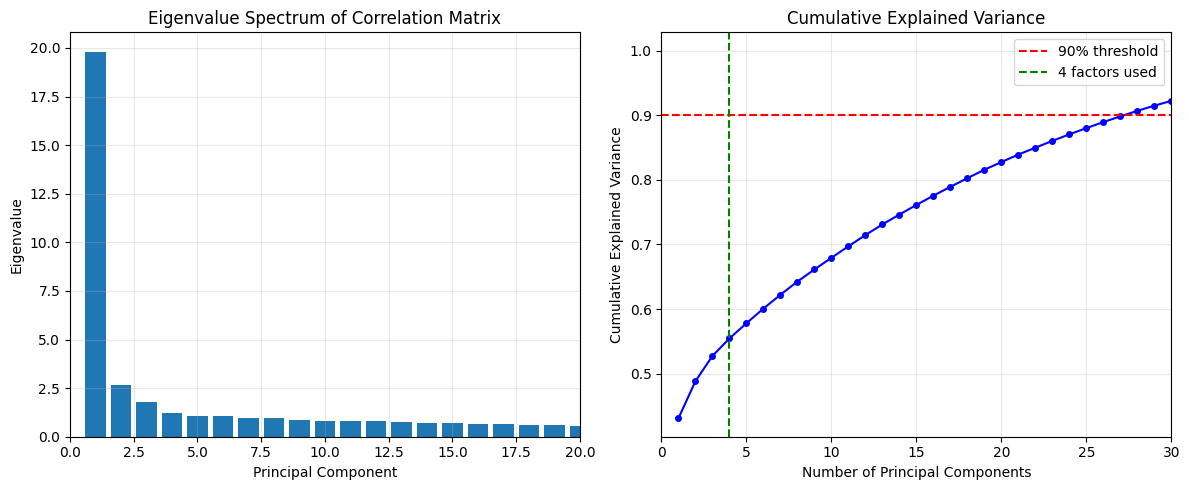

In [22]:
# Plot eigenvalue spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(factor_model["eigenvalues"]) + 1), factor_model["eigenvalues"])
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Correlation Matrix")
plt.xlim(0, 20)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_var = (
    np.cumsum(factor_model["eigenvalues"]) / factor_model["eigenvalues"].sum()
)
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, "b-o", markersize=4)
plt.axhline(y=0.9, color="r", linestyle="--", label="90% threshold")
plt.axvline(x=n_factors, color="g", linestyle="--", label=f"{n_factors} factors used")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 30)

plt.tight_layout()
plt.show()

# 2. Ornstein-Uhlenbeck Process for Residuals

The cumulative residuals are modeled as an Ornstein-Uhlenbeck (O-U) process:

$$dX_t = \kappa (m - X_t) dt + \sigma dW_t$$

where:

- $\kappa$ is the **mean-reversion speed** (how fast the process reverts to the mean)
- $m$ is the **equilibrium level** (long-term mean)
- $\sigma$ is the **volatility** of the process

The **equilibrium standard deviation** is: $\sigma_{eq} = \frac{\sigma}{\sqrt{2\kappa}}$

The **half-life** of mean reversion is: $\tau_{1/2} = \frac{\ln(2)}{\kappa}$


In [23]:
# Compute cumulative residuals
cumulative_residuals = estimate_ou_window_residuals(
    candidate_window, factor_model["factors"], ou_estimation_window
)["residuals"]

# Estimate O-U parameters
cum_residuals_ou = cumulative_residuals.iloc[-ou_estimation_window:]
ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252, center_ou_means=False)

# Display O-U parameters for a few assets
print(
    f"O-U Parameters for selected assets ({ou_estimation_window}-day window, centered means):"
)
print(f"{'Asset':<15} {'Kappa':>10} {'Half-life':>12} {'Sigma_eq':>12} {'m':>10}")
print("-" * 60)
for asset in list(ou_params.keys())[:10]:
    params = ou_params[asset]
    half_life_days = params["half_life"] * 252
    print(
        f"{asset:<15} {params['kappa']:>10.2f} {half_life_days:>10.1f} d {params['sigma_eq']:>12.4f} {params['m']:>10.4f}"
    )

O-U Parameters for selected assets (60-day window, centered means):
Asset                Kappa    Half-life     Sigma_eq          m
------------------------------------------------------------
ABI.BR               60.15        2.9 d       0.0100     0.0030
AD.AS                15.27       11.4 d       0.0302     0.0304
ADSGn.DE             16.83       10.4 d       0.0190     0.0210
AIR.PA               45.27        3.9 d       0.0235    -0.0129
AIRP.PA              28.12        6.2 d       0.0096    -0.0054
ALVG.DE              47.54        3.7 d       0.0080     0.0033
ASML.AS              19.00        9.2 d       0.0230    -0.0157
AXAF.PA              45.64        3.8 d       0.0134    -0.0079
BASFn.DE             18.33        9.5 d       0.0126     0.0141
BAYGn.DE            144.81        1.2 d       0.0072    -0.0071


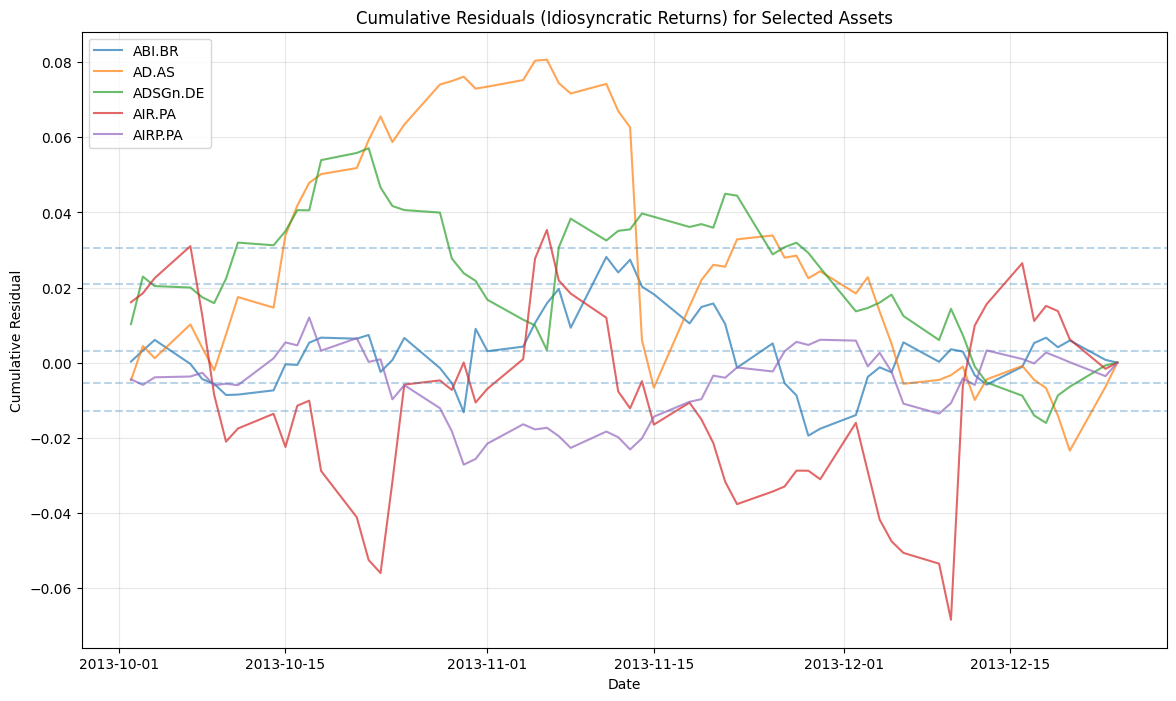

In [24]:
# Plot cumulative residuals for a few assets
sample_assets = list(cumulative_residuals.columns)[:5]

plt.figure(figsize=(14, 8))
for asset in sample_assets:
    plt.plot(
        cumulative_residuals.index, cumulative_residuals[asset], label=asset, alpha=0.7
    )
    # Add equilibrium level
    m = ou_params[asset]["m"]
    plt.axhline(y=m, linestyle="--", alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Cumulative Residual")
plt.title("Cumulative Residuals (Idiosyncratic Returns) for Selected Assets")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

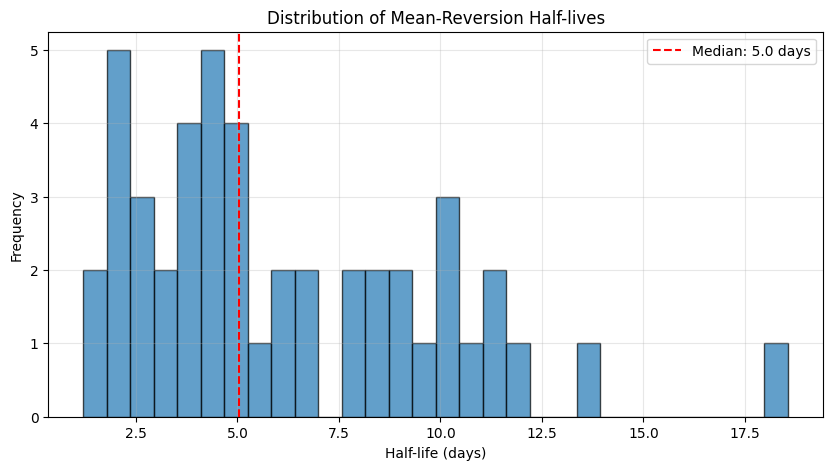

Half-life statistics:
  Mean: 6.2 days
  Median: 5.0 days
  Std: 3.8 days


In [25]:
# Distribution of half-lives
half_lives = pd.Series(
    {asset: params["half_life"] * 252 for asset, params in ou_params.items()}
)
half_lives = half_lives[half_lives < 100]  # Filter outliers

plt.figure(figsize=(10, 5))
plt.hist(half_lives, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Half-life (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Mean-Reversion Half-lives")
plt.axvline(
    half_lives.median(),
    color="r",
    linestyle="--",
    label=f"Median: {half_lives.median():.1f} days",
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Half-life statistics:")
print(f"  Mean: {half_lives.mean():.1f} days")
print(f"  Median: {half_lives.median():.1f} days")
print(f"  Std: {half_lives.std():.1f} days")

# 3. S-Score and Trading Signals

The modified **s-score** measures how far the current cumulative residual is from its equilibrium, accounting for the residual drift:

$$s_{mod, t} = s_t - \frac{\alpha}{\kappa \sigma_{eq}} =  \frac{X_t - m}{\sigma_{eq}} - \frac{\alpha}{\kappa \sigma_{eq}} $$

Trading rules:

- **Buy to Open** (enter long): $s < -s_{bo}$ (price is too low)
- **Sell to Close** (exit long): $s > -s_{bc}$ (price recovered)
- **Sell to Open** (enter short): $s > s_{so}$ (price is too high)
- **Buy to Close** (exit short): $s < s_{sc}$ (price reverted)


In [26]:
# Compute s-scores
s_scores = compute_s_score(cumulative_residuals, ou_params)

print("S-score statistics across all assets:")
print(
    f"  Mean: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].mean():.2f}"
)
print(
    f"  Std: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].std():.2f}"
)
print(f"  Min: {np.nanmin(s_scores.values):.2f}")
print(f"  Max: {np.nanmax(s_scores.values):.2f}")

S-score statistics across all assets:
  Mean: 0.00
  Std: 1.01
  Min: -2.76
  Max: 2.99


# 4. Rolling Backtest of Statistical Arbitrage Strategy

We now implement a rolling backtest where:

1. At each trading day, we re-estimate the factor model (252-day window) and O-U parameters (60-day window)
2. We compute s-scores and update trading positions **maintaining state across days**
3. We track the portfolio performance


In [27]:
# Storage for results
all_positions = {}
all_s_scores = {}
all_ou_params = {}
all_factor_models = {}

current_positions: dict[str, float] = {}

for rebalance_date in performance.index:
    cur_performance, cur_window_diagnostics = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_window_diagnostics["row_count"] < estimation_window
        or cur_performance.shape[1] == 0
    ):
        continue

    reb_date = rebalance_date.to_pydatetime().date()
    print(f"Processing: {reb_date}")

    # 1. Estimate factor model
    factor_model = estimate_factor_model(cur_performance, n_factors=n_factors)
    all_factor_models[reb_date] = factor_model

    # 2. Compute the residuals needed to estimate the mean-reversion parameters
    ou_window_results = estimate_ou_window_residuals(
    cur_performance, factor_model["factors"], ou_estimation_window
    )
    cum_residuals_ou = ou_window_results["residuals"].iloc[-ou_estimation_window:]
    alphas_ou = ou_window_results["alphas"] # We need alphas to compute the modified s-score, but we can also compute the basic s-score without them

    # 3. Estimate O-U parameters
    ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252, center_ou_means=False)
    all_ou_params[reb_date] = ou_params

    # 4. Filter assets
    valid_assets = [
        asset
        for asset, params in ou_params.items()
        if params["kappa"] >= min_mean_reversion_speed
    ]

    # 5. S-score
    cur_s_scores = compute_s_score(cum_residuals_ou, ou_params, modified=True, alphas=alphas_ou).iloc[-1]
    all_s_scores[reb_date] = cur_s_scores

    # Update positions carrying over previous day's state
    current_positions = update_positions(
        current_positions=current_positions,
        cur_s_scores=cur_s_scores, 
        valid_assets=valid_assets,
        s_bo=s_bo,
        s_so=s_so,
        s_bc=s_bc,
        s_sc=s_sc,
    )
    all_positions[reb_date] = current_positions.copy()

Processing: 2013-12-24
Processing: 2013-12-27
Processing: 2013-12-30
Processing: 2013-12-31
Processing: 2014-01-02
Processing: 2014-01-03
Processing: 2014-01-06
Processing: 2014-01-07
Processing: 2014-01-08
Processing: 2014-01-09
Processing: 2014-01-10
Processing: 2014-01-13
Processing: 2014-01-14
Processing: 2014-01-15
Processing: 2014-01-16
Processing: 2014-01-17
Processing: 2014-01-20
Processing: 2014-01-21
Processing: 2014-01-22
Processing: 2014-01-23
Processing: 2014-01-24
Processing: 2014-01-27
Processing: 2014-01-28
Processing: 2014-01-29
Processing: 2014-01-30
Processing: 2014-01-31
Processing: 2014-02-03
Processing: 2014-02-04
Processing: 2014-02-05
Processing: 2014-02-06
Processing: 2014-02-07
Processing: 2014-02-10
Processing: 2014-02-11
Processing: 2014-02-12
Processing: 2014-02-13
Processing: 2014-02-14
Processing: 2014-02-17
Processing: 2014-02-18
Processing: 2014-02-19
Processing: 2014-02-20
Processing: 2014-02-21
Processing: 2014-02-24
Processing: 2014-02-25
Processing:

In [28]:
# Build portfolio weights time series
positions_df = pd.DataFrame(all_positions).T
positions_df.index = pd.to_datetime(positions_df.index)
positions_df = positions_df.fillna(0)

# Equal weight among active positions
weights = compute_portfolio_weights(positions_df)

print("Position statistics:")
print(f"  Total rebalance dates: {len(positions_df)}")
print(
    f"  Average number of long positions: {(positions_df > 0).sum(axis=1).mean():.1f}"
)
print(
    f"  Average number of short positions: {(positions_df < 0).sum(axis=1).mean():.1f}"
)
print(f"  Average total positions: {(positions_df != 0).sum(axis=1).mean():.1f}")

Position statistics:
  Total rebalance dates: 2347
  Average number of long positions: 10.2
  Average number of short positions: 10.0
  Average total positions: 20.1


In [29]:
# Backtest the strategy
cumulative_returns = backtest(weights, performance)
cumulative_returns_with_costs = backtest(
    weights, performance, transaction_costs=transaction_costs
)

# Compute strategy statistics
stats = compute_strategy_statistics(cumulative_returns.dropna())

print("Strategy Performance:")
print(f"  Total Return: {stats['total_return']:.2%}")
print(f"  Annualized Return: {stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {stats['max_drawdown']:.2%}")

# Compute strategy statistics
stats = compute_strategy_statistics(cumulative_returns_with_costs.dropna())

print("Strategy Performance:")
print(f"  Total Return: {stats['total_return']:.2%}")
print(f"  Annualized Return: {stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {stats['max_drawdown']:.2%}")

Strategy Performance:
  Total Return: 31.85%
  Annualized Return: 3.02%
  Annualized Volatility: 5.60%
  Sharpe Ratio: 0.54
  Maximum Drawdown: -8.50%
Strategy Performance:
  Total Return: 0.67%
  Annualized Return: 0.07%
  Annualized Volatility: 5.60%
  Sharpe Ratio: 0.01
  Maximum Drawdown: -9.75%


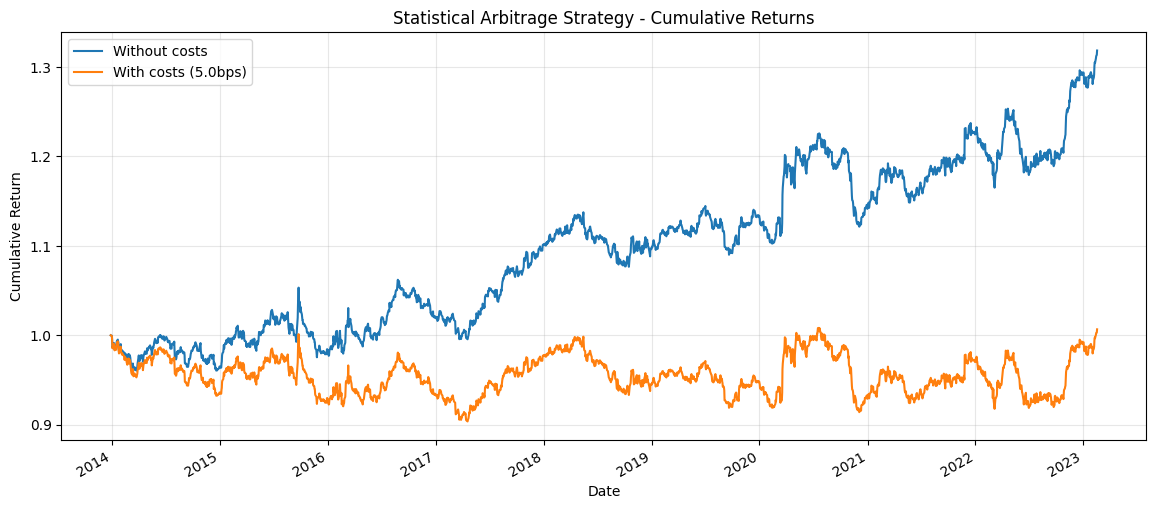

In [30]:
# Plot cumulative returns
plt.figure(figsize=(14, 6))
cumulative_returns.plot(label="Without costs", linewidth=1.5)
cumulative_returns_with_costs.plot(
    label=f"With costs ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

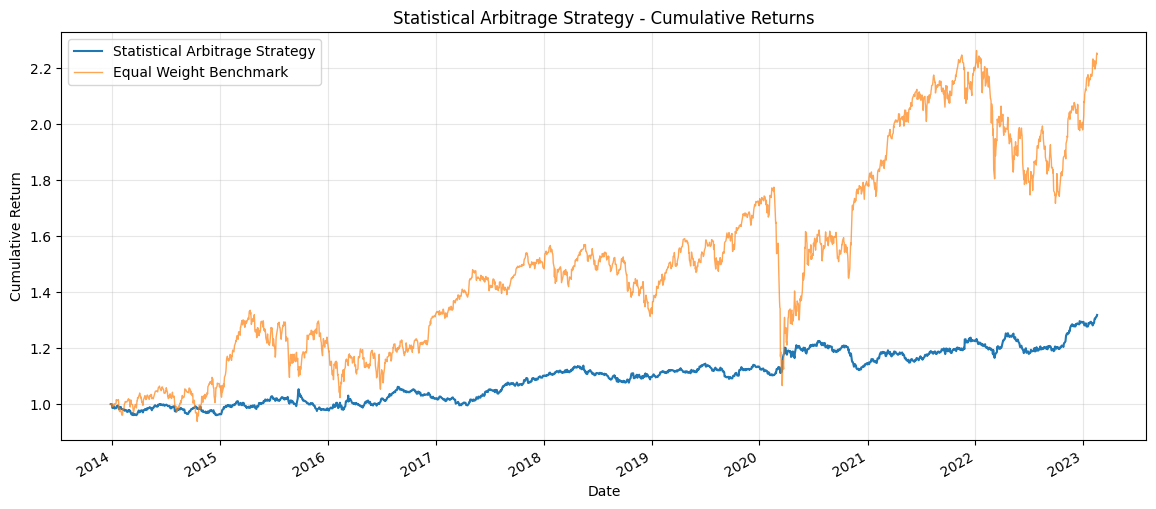

In [31]:
# Plot cumulative returns
plt.figure(figsize=(14, 6))
cumulative_returns.plot(label="Statistical Arbitrage Strategy", linewidth=1.5)

# Add benchmark (equal-weighted portfolio)
equal_weight_benchmark = (1 + performance.mean(axis=1)).cumprod()
equal_weight_benchmark = equal_weight_benchmark.reindex(
    cumulative_returns.index
).ffill()
equal_weight_benchmark = (
    equal_weight_benchmark / equal_weight_benchmark.iloc[0] * cumulative_returns.iloc[0]
)
equal_weight_benchmark.plot(label="Equal Weight Benchmark", linewidth=1, alpha=0.7)


plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

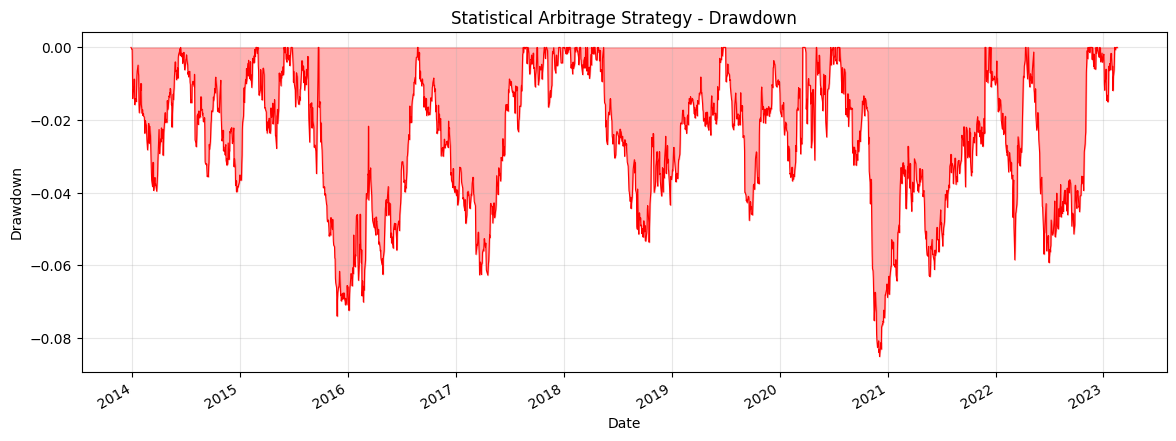

In [32]:
# Plot drawdown
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max

plt.figure(figsize=(14, 5))
drawdown.plot(color="red", linewidth=0.8)
plt.fill_between(drawdown.index, 0, drawdown.values, color="red", alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Statistical Arbitrage Strategy - Drawdown")
plt.grid(alpha=0.3)
plt.show()

# 5. Analysis of Strategy Characteristics


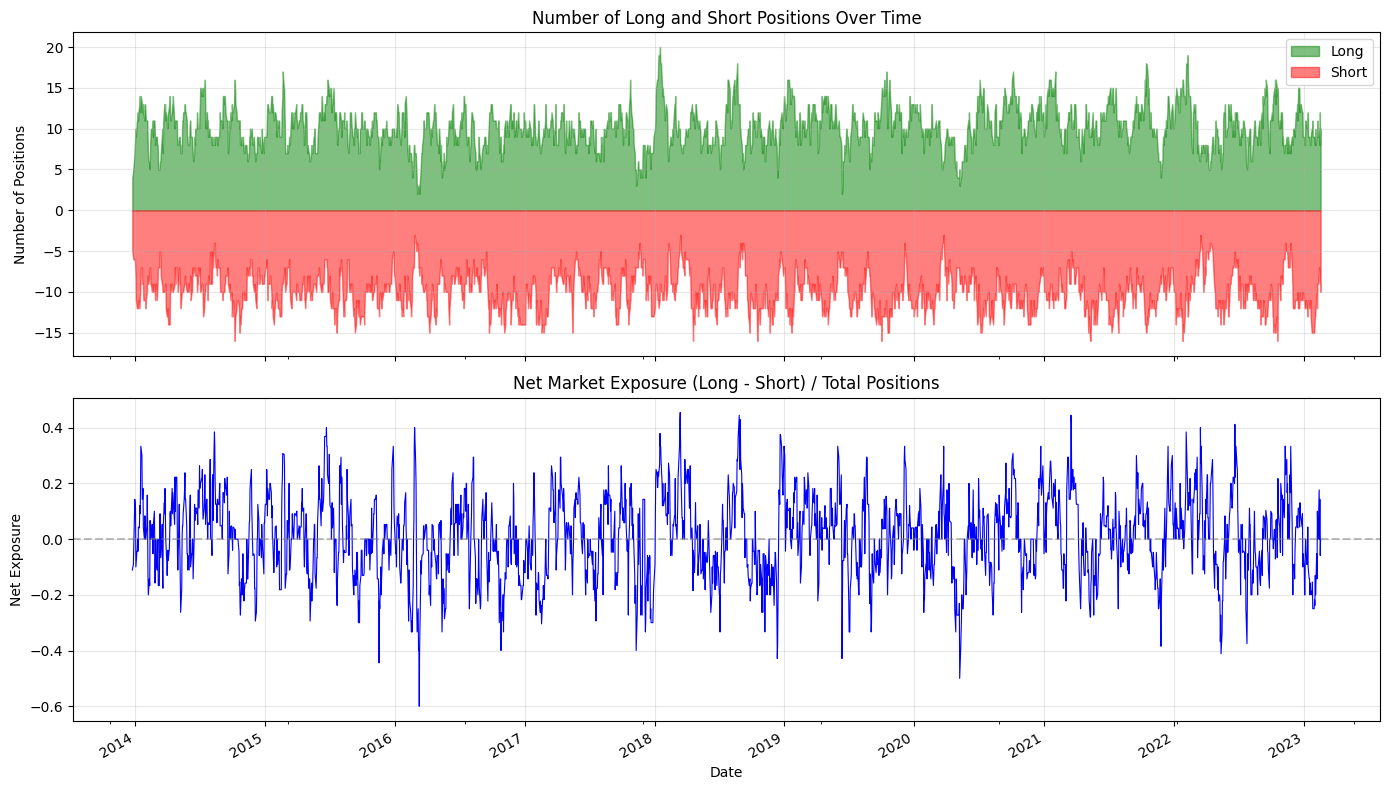

In [33]:
# Number of positions over time
n_long = (positions_df > 0).sum(axis=1)
n_short = (positions_df < 0).sum(axis=1)
n_total = (positions_df != 0).sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ax1.fill_between(n_long.index, 0, n_long.values, color="green", alpha=0.5, label="Long")
ax1.fill_between(
    n_short.index, 0, -n_short.values, color="red", alpha=0.5, label="Short"
)
ax1.set_ylabel("Number of Positions")
ax1.set_title("Number of Long and Short Positions Over Time")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
net_exposure = positions_df.sum(axis=1) / n_total.replace(0, np.nan)
net_exposure.plot(ax=ax2, color="blue", linewidth=0.8)
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Net Exposure")
ax2.set_xlabel("Date")
ax2.set_title("Net Market Exposure (Long - Short) / Total Positions")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

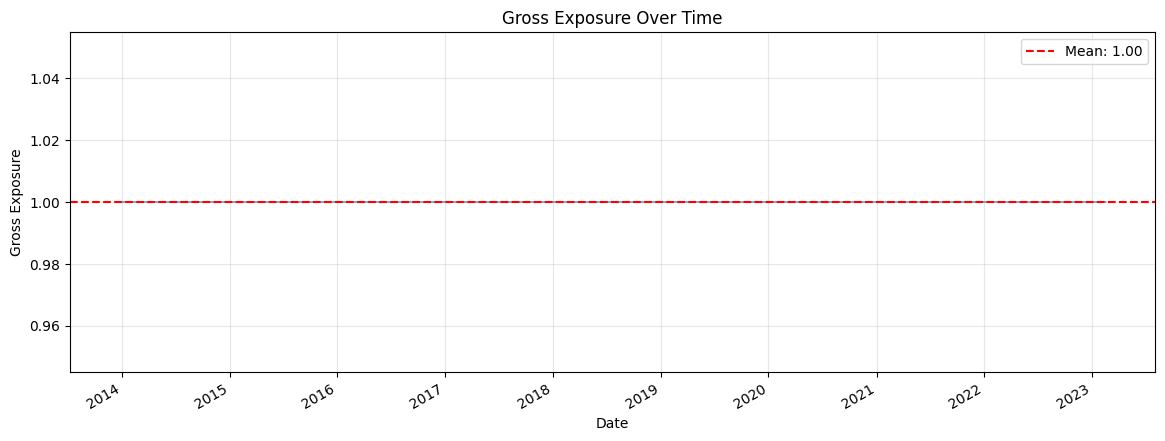

In [34]:
# Gross exposure over time
gross_exposure = weights.abs().sum(axis=1).round(6)

plt.figure(figsize=(14, 5))
gross_exposure.plot(linewidth=0.8)
plt.axhline(
    y=gross_exposure.mean(),
    color="r",
    linestyle="--",
    label=f"Mean: {gross_exposure.mean():.2f}",
)
plt.xlabel("Date")
plt.ylabel("Gross Exposure")
plt.title("Gross Exposure Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

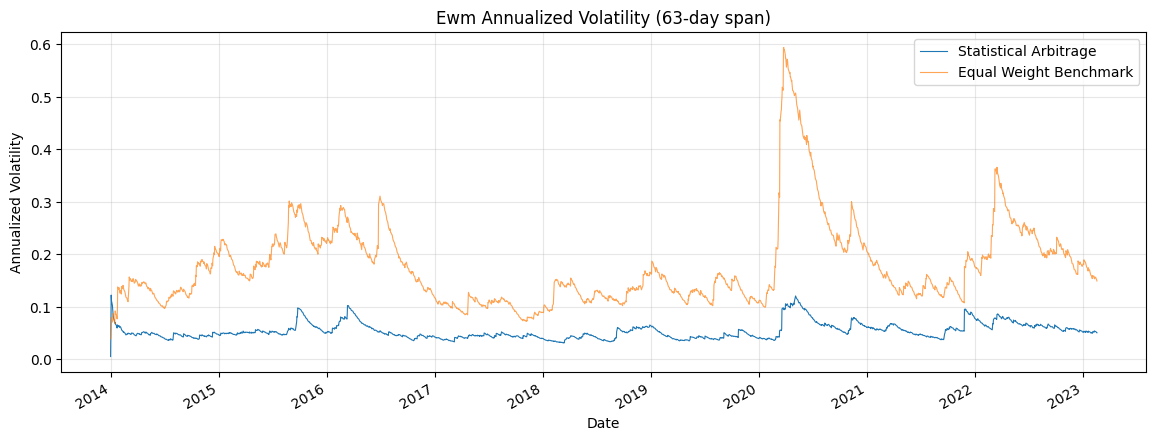

In [35]:
# Ewm volatility of strategy returns
strategy_returns = cumulative_returns.pct_change().dropna()
ewm_vol = strategy_returns.ewm(span=63).std() * np.sqrt(252)

benchmark_returns = equal_weight_benchmark.pct_change().dropna()
benchmark_ewm_vol = benchmark_returns.ewm(span=63).std() * np.sqrt(252)

plt.figure(figsize=(14, 5))
ewm_vol.plot(label="Statistical Arbitrage", linewidth=0.8)
benchmark_ewm_vol.plot(label="Equal Weight Benchmark", linewidth=0.8, alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("Ewm Annualized Volatility (63-day span)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Sensitivity Analysis

## 6.1 Sensitivity to s-score entry threshold


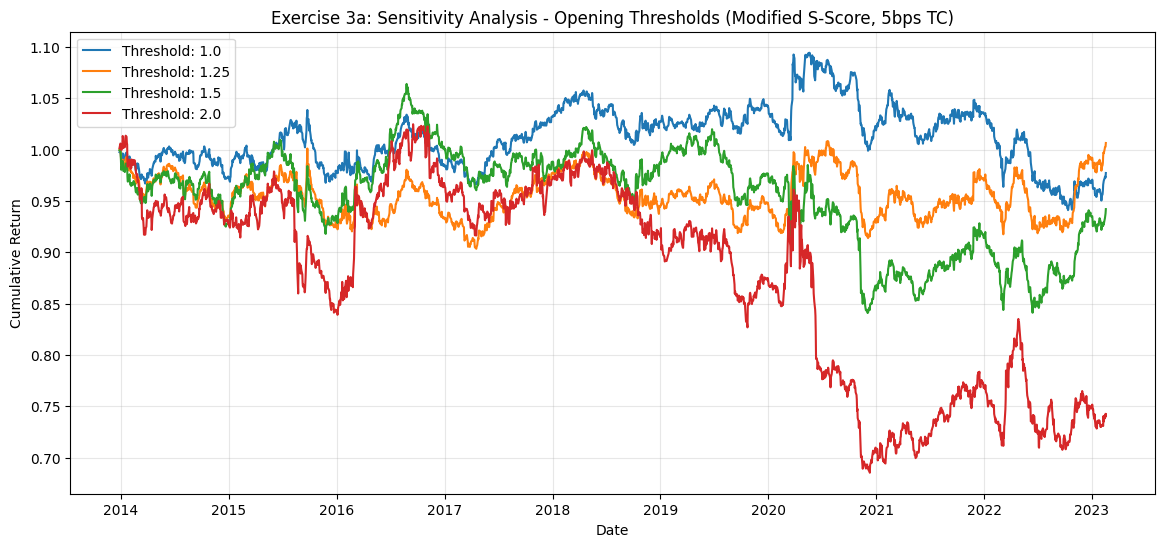


--- Sensitivity Analysis Summary ---
          Total Return Ann. Volatility Sharpe Ratio  Max Drawdown
Threshold                                                        
1.00            -2.04%           4.98%        -0.04     -0.140082
1.25             0.67%           5.60%         0.01     -0.097515
1.50            -5.73%           6.70%        -0.09     -0.209443
2.00           -25.85%           9.66%        -0.33     -0.331197


In [36]:
# Sensitivity analysis parameters
opening_thresholds = [1.0, 1.25, 1.5, 2.0]
exit_level = 0.50  # symmetric thresholds as per assignment
tc = 5e-4
 
# Storage for s-scores and valid assets across rebalance dates
all_s_scores_61 = {}
all_valid_assets_61 = {}
 
# Rolling estimation loop — same pipeline as Q2
for rebalance_date in performance.index:
    cur_performance, cur_window_diagnostics = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_window_diagnostics["row_count"] < estimation_window
        or cur_performance.shape[1] == 0
    ):
        continue
 
    # 1. Estimate factor model on the 252-day window
    factor_model = estimate_factor_model(cur_performance, n_factors=n_factors)
 
    # 2. Compute cumulative residuals on the last 60 days only
    # (OLS and cumsum are done inside estimate_ou_window_residuals)
    ou_window_results = estimate_ou_window_residuals(
        cur_performance, factor_model["factors"], ou_estimation_window
    )
    cum_residuals_ou = ou_window_results["residuals"].iloc[-ou_estimation_window:]
    alphas_ou = ou_window_results["alphas"]  # needed for modified s-score (formula 17)
 
    # 3. Estimate O-U parameters
    ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252, center_ou_means=False)
 
    # 4. Filter assets by mean-reversion speed
    valid_assets = [
        asset
        for asset, params in ou_params.items()
        if params["kappa"] >= min_mean_reversion_speed
    ]
 
    # 5. Compute modified s-scores (includes drift term)
    cur_s_scores = compute_s_score(cum_residuals_ou, ou_params, modified=True, alphas=alphas_ou)
 
    all_s_scores_61[rebalance_date] = cur_s_scores.iloc[-1]  # signal for today
    all_valid_assets_61[rebalance_date] = valid_assets
 
# Run backtest separately for each threshold (reuses precomputed s-scores)
threshold_results = {}
performance_metrics = []
 
for threshold in opening_thresholds:
    current_positions: dict[str, float] = {}
    all_positions = {}
 
    for date in all_s_scores_61:
        current_positions = update_positions(
            current_positions=current_positions,
            cur_s_scores=all_s_scores_61[date],
            valid_assets=all_valid_assets_61[date],
            s_bo=threshold,
            s_so=threshold,
            s_bc=exit_level,
            s_sc=exit_level,
        )
        all_positions[date] = current_positions.copy()
 
    # Build weights from positions
    positions_df = pd.DataFrame(all_positions).T
    positions_df.index = pd.to_datetime(positions_df.index)
    positions_df = positions_df.fillna(0)
 
    weights_df = compute_portfolio_weights(positions_df)
 
    # Note: no .shift(1) needed — backtest() shifts weights internally
    pnl = backtest(
        portfolios=weights_df,
        returns=performance,
        transaction_costs=tc,
    )
    threshold_results[threshold] = pnl
 
    # Compute statistics using the utility function
    stats = compute_strategy_statistics(pnl)

    performance_metrics.append({
        "Threshold": threshold,
        "Total Return": stats["total_return"],
        "Ann. Volatility": stats["annualized_volatility"],
        "Sharpe Ratio": stats["sharpe_ratio"],
        "Max Drawdown": stats["max_drawdown"],
    })
 
# Plot cumulative returns for each threshold
plt.figure(figsize=(14, 6))
for threshold, pnl in threshold_results.items():
    plt.plot(pnl, label=f"Threshold: {threshold}")
 
plt.title("Exercise 3a: Sensitivity Analysis - Opening Thresholds (Modified S-Score, 5bps TC)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
 
# Print summary table
df_metrics = pd.DataFrame(performance_metrics).set_index("Threshold")
print("\n--- Sensitivity Analysis Summary ---")
print(df_metrics.to_string(formatters={
    "Total Return": "{:.2%}".format,
    "Ann. Volatility": "{:.2%}".format,
    "Sharpe Ratio": "{:.2f}".format,
}))
 

## 6.2 Fixed factors vs variable factor selection


In [38]:
# ── 6.2  Variable number of PCs — target explained variance ────────────────
target_variances = [0.40, 0.55, 0.65, 0.75]
tc = 5e-4

# They need to be redifined (they have been changed in 5.1)
s_bo = 1.25 
s_so = 1.25 
s_bc = 0.50 
s_sc = 0.50 

# Storage — one entry per target level
var_positions      = {tv: {} for tv in target_variances}
var_current_pos    = {tv: {} for tv in target_variances}
n_factors_history  = {tv: {} for tv in target_variances}

dates_processed = 0

for rebalance_date in performance.index:
    cur_performance, diag = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if diag["row_count"] < estimation_window or cur_performance.shape[1] == 0:
        continue

    reb_date = rebalance_date.to_pydatetime().date()
    dates_processed += 1
    if dates_processed % 250 == 0:
        print(f"Processing: {reb_date}  ({dates_processed} dates done)")

    # Eigenvalues from the correlation matrix — computed ONCE per date
    eigenvalues_all = np.linalg.eigh(cur_performance.corr().values)[0][::-1]
    cum_var = np.cumsum(eigenvalues_all) / eigenvalues_all.sum()

    for target in target_variances:
        # Minimum number of PCs whose cumulative variance reaches target
        n_fac = int(np.searchsorted(cum_var, target)) + 1
        n_fac = max(1, min(n_fac, len(eigenvalues_all)))
        n_factors_history[target][reb_date] = n_fac

        # 1. Factor model with variable number of PCs
        factor_model = estimate_factor_model(cur_performance, n_factors=n_fac)

        # 2. Residuals on the 60-day OU window
        ou_result = estimate_ou_window_residuals(
            cur_performance, factor_model["factors"], ou_estimation_window
        )
        cum_residuals_ou = ou_result["residuals"].iloc[-ou_estimation_window:]
        alphas_ou = ou_result["alphas"]

        # 3. OU parameters
        ou_params = estimate_all_ou_parameters(
            cum_residuals_ou, dt=1 / 252, center_ou_means=False
        )

        # 4. Filter by mean-reversion speed
        valid_assets = [
            asset for asset, p in ou_params.items()
            if p["kappa"] >= min_mean_reversion_speed
        ]

        # 5. Modified s-score and position update
        cur_s = compute_s_score(
            cum_residuals_ou, ou_params, modified=True, alphas=alphas_ou
        )
        var_current_pos[target] = update_positions(
            current_positions=var_current_pos[target],
            cur_s_scores=cur_s.iloc[-1],
            valid_assets=valid_assets,
            s_bo=s_bo, s_so=s_so, s_bc=s_bc, s_sc=s_sc,
        )
        var_positions[target][reb_date] = var_current_pos[target].copy()

print(f"Done — {dates_processed} rebalance dates processed.")


# ── Backtest each target level ─────────────────────────────────────────────
var_results = {}
performance_metrics_62 = []

for target in target_variances:
    pos_df = pd.DataFrame(var_positions[target]).T
    pos_df.index = pd.to_datetime(pos_df.index)
    pos_df = pos_df.fillna(0)

    weights_var = compute_portfolio_weights(pos_df)
    pnl = backtest(weights_var, performance, transaction_costs=tc)
    var_results[target] = pnl

    daily_rets = pnl.pct_change().dropna()
    ann_vol = daily_rets.std() * np.sqrt(252)
    sharpe = (daily_rets.mean() * 252) / ann_vol if ann_vol > 0 else 0.0

    performance_metrics_62.append({
        "Strategy": f"Variable ({target:.0%})",
        "Total Return": pnl.iloc[-1] / pnl.iloc[0] - 1,
        "Ann. Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
    })

# Add fixed 4-factor baseline from section 4
# Add fixed 4-factor baseline from section 4 (reusing 6.1 results)
performance_metrics_62.append({
    "Strategy": "Fixed (4 PCs)",
    "Total Return": df_metrics.loc[1.25, "Total Return"],  
    "Ann. Volatility": df_metrics.loc[1.25, "Ann. Volatility"],  
    "Sharpe Ratio": df_metrics.loc[1.25, "Sharpe Ratio"],
})

Processing: 2014-12-15  (250 dates done)
Processing: 2015-12-07  (500 dates done)
Processing: 2016-11-25  (750 dates done)
Processing: 2017-11-16  (1000 dates done)
Processing: 2018-11-08  (1250 dates done)
Processing: 2019-11-01  (1500 dates done)
Processing: 2020-10-26  (1750 dates done)
Processing: 2021-10-15  (2000 dates done)
Processing: 2022-10-04  (2250 dates done)
Done — 2347 rebalance dates processed.


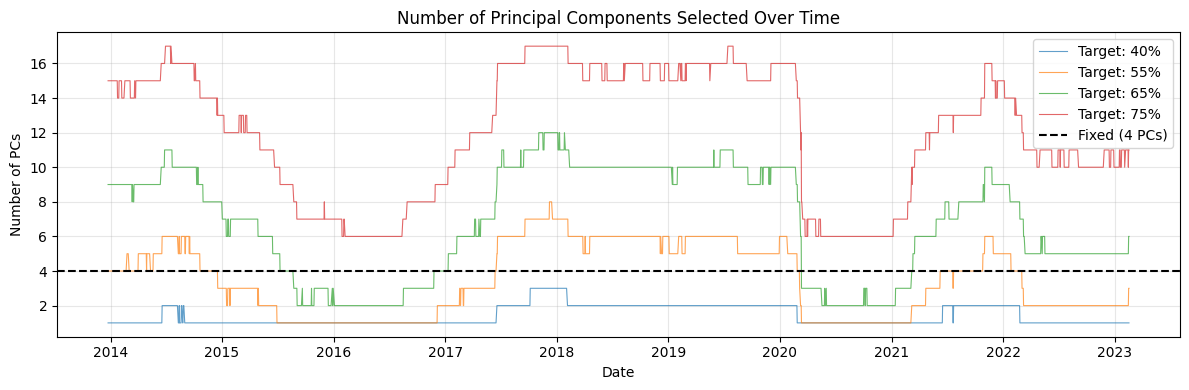

In [39]:
# ── Plot 1: Number of PCs selected over time ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
for target in target_variances:
    series = pd.Series(n_factors_history[target])
    series.index = pd.to_datetime(series.index)
    ax.plot(series, label=f"Target: {target:.0%}", alpha=0.7, linewidth=0.8)
ax.axhline(y=4, color="black", linestyle="--", label="Fixed (4 PCs)")
ax.set_xlabel("Date")
ax.set_ylabel("Number of PCs")
ax.set_title("Number of Principal Components Selected Over Time")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


c:\Users\stefa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


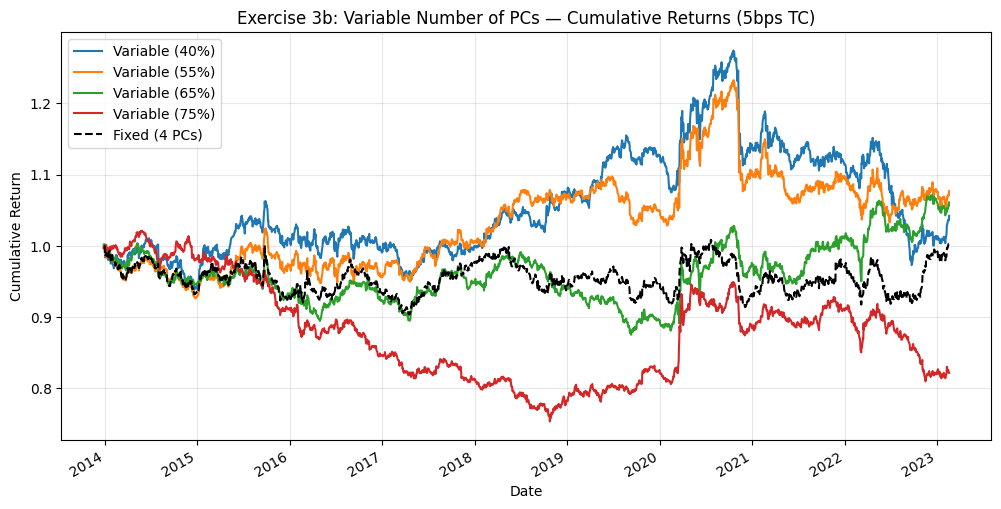


--- Variable PCs: Sensitivity Analysis Summary ---
               Total Return Ann. Volatility Sharpe Ratio
Strategy                                                
Variable (40%)        4.55%           6.83%         0.10
Variable (55%)        7.68%           6.58%         0.15
Variable (65%)        5.89%           5.62%         0.14
Variable (75%)      -17.60%           5.36%        -0.36
Fixed (4 PCs)         0.67%           5.60%         0.01


In [40]:
# ── Plot 1: Cumulative returns ─────────────────────────────────────────────
plt.figure(figsize=(12, 6))
for target, pnl in var_results.items():
    plt.plot(pnl, label=f"Variable ({target:.0%})")
cumulative_returns_with_costs.plot(
    label="Fixed (4 PCs)", linestyle="--", color="black", linewidth=1.5
)
plt.title("Exercise 3b: Variable Number of PCs — Cumulative Returns (5bps TC)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
df_metrics_62 = pd.DataFrame(performance_metrics_62).set_index("Strategy")
print("\n--- Variable PCs: Sensitivity Analysis Summary ---")
print(df_metrics_62.to_string(formatters={
    "Total Return": "{:.2%}".format,
    "Ann. Volatility": "{:.2%}".format,
    "Sharpe Ratio": "{:.2f}".format,
}))

# 7 Trading Time: Volume-Adjusted Returns

### Trading Time

The paper proposes measuring returns in **trading time** rather than calendar time.
The idea: price moves on low-volume days carry more information than moves on high-volume days.

The adjusted return:

$$\bar{R}_{i,t} = R_{i,t} \cdot \frac{\langle \delta V_i \rangle}{V_{i,t}}$$

where $\langle \delta V_i \rangle$ is the trailing average daily volume and $V_{i,t}$ is the actual volume on day $t$.

This amplifies price moves on quiet days and dampens moves on heavy-volume days.
We run the full backtest pipeline on these adjusted returns and compare to calendar time.


In [41]:
vol_adjusted_returns = compute_volume_adjusted_returns(
    returns=performance,
    volume=volume,
    trailing_window=ou_estimation_window,  # 60 days, same as OU window
)

Rolling backtest on volume-adjusted returns

In [42]:
# Storage for results
vol_all_positions = {}
vol_current_positions: dict[str, float] = {}

for rebalance_date in vol_adjusted_returns.index:
    cur_performance_vol, cur_diag_vol = prepare_rolling_estimation_window(
        returns=vol_adjusted_returns,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_diag_vol["row_count"] < estimation_window
        or cur_performance_vol.shape[1] == 0
    ):
        continue

    # 1. Estimate factor model on the 252-day window
    vol_factor_model = estimate_factor_model(cur_performance_vol, n_factors=n_factors)

    # 2. Compute cumulative residuals on the last 60 days only
    vol_ou_results = estimate_ou_window_residuals(
        cur_performance_vol, vol_factor_model["factors"], ou_estimation_window
    )
    vol_cum_residuals = vol_ou_results["residuals"].iloc[-ou_estimation_window:]
    vol_alphas = vol_ou_results["alphas"]  # needed for modified s-score (formula 17)

    # 3. Estimate O-U parameters
    vol_ou_params = estimate_all_ou_parameters(
        vol_cum_residuals, dt=1 / 252, center_ou_means=False
    )

    # 4. Filter assets by mean-reversion speed
    vol_valid_assets = [
        asset
        for asset, params in vol_ou_params.items()
        if params["kappa"] >= min_mean_reversion_speed
    ]

    # 5. Compute modified s-scores (includes drift term)
    vol_s_scores = compute_s_score(
        vol_cum_residuals, vol_ou_params, modified=True, alphas=vol_alphas
    )

    # Update positions carrying over previous day's state
    vol_current_positions = update_positions(
        current_positions=vol_current_positions,
        cur_s_scores=vol_s_scores.iloc[-1],
        valid_assets=vol_valid_assets,
        s_bo=s_bo,
        s_so=s_so,
        s_bc=s_bc,
        s_sc=s_sc,
    )
    vol_all_positions[rebalance_date] = vol_current_positions.copy()

In [43]:
# Build portfolio weights time series
vol_positions_df = pd.DataFrame(vol_all_positions).T
vol_positions_df.index = pd.to_datetime(vol_positions_df.index)
vol_positions_df = vol_positions_df.fillna(0)

vol_weights = compute_portfolio_weights(vol_positions_df)

print("Position statistics (volume-adjusted):")
print(f"  Total rebalance dates: {len(vol_positions_df)}")
print(f"  Average number of long positions: {(vol_positions_df > 0).sum(axis=1).mean():.1f}")
print(f"  Average number of short positions: {(vol_positions_df < 0).sum(axis=1).mean():.1f}")
print(f"  Average total positions: {(vol_positions_df != 0).sum(axis=1).mean():.1f}")

Position statistics (volume-adjusted):
  Total rebalance dates: 2287
  Average number of long positions: 9.9
  Average number of short positions: 9.8
  Average total positions: 19.7


In [44]:
# Backtest — positions from vol-adjusted signals, returns are ORIGINAL (real prices)
vol_cumulative_returns = backtest(vol_weights, performance)
vol_cumulative_returns_with_costs = backtest(
    vol_weights, performance, transaction_costs=transaction_costs
)

# Compute strategy statistics
vol_stats = compute_strategy_statistics(vol_cumulative_returns_with_costs.dropna())

print("Strategy Performance (Trading Time, 5bps TC):")
print(f"  Total Return: {vol_stats['total_return']:.2%}")
print(f"  Annualized Return: {vol_stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {vol_stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {vol_stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {vol_stats['max_drawdown']:.2%}")

Strategy Performance (Trading Time, 5bps TC):
  Total Return: 1.65%
  Annualized Return: 0.18%
  Annualized Volatility: 6.07%
  Sharpe Ratio: 0.03
  Maximum Drawdown: -16.55%


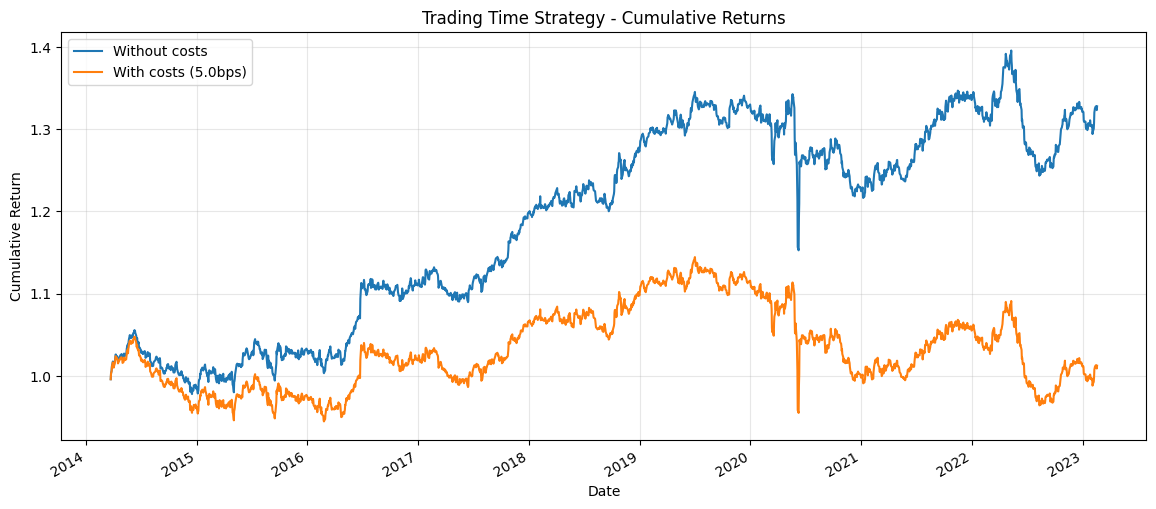

In [45]:
# Plot cumulative returns — with and without transaction costs
plt.figure(figsize=(14, 6))
vol_cumulative_returns.plot(label="Without costs", linewidth=1.5)
vol_cumulative_returns_with_costs.plot(
    label=f"With costs ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5
)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Trading Time Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

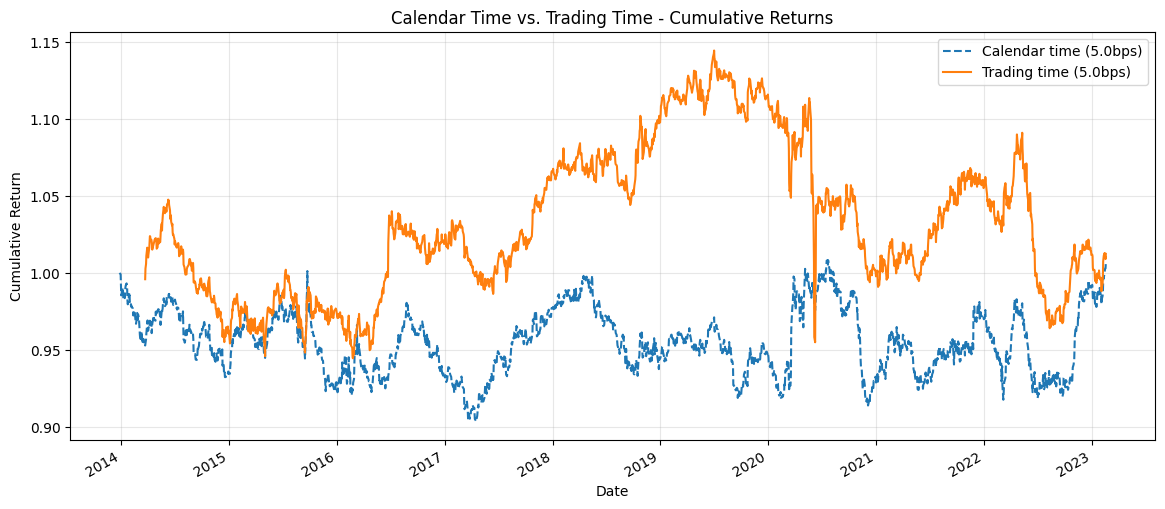

In [46]:
# Compare calendar time vs trading time (both with 5bps TC)
plt.figure(figsize=(14, 6))
cumulative_returns_with_costs.plot(
    label=f"Calendar time ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5, linestyle="--"
)
vol_cumulative_returns_with_costs.plot(
    label=f"Trading time ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5
)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Calendar Time vs. Trading Time - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

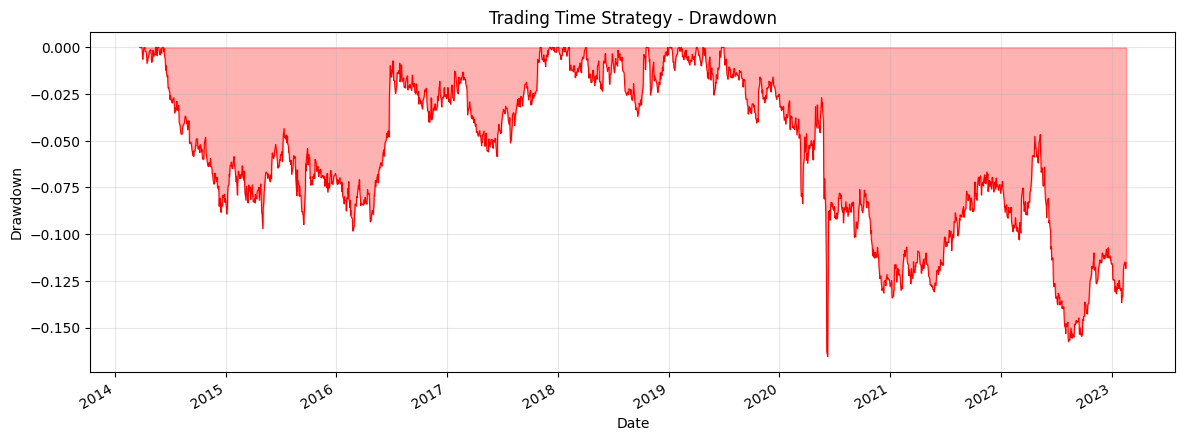

In [47]:
# Plot drawdown
vol_rolling_max = vol_cumulative_returns_with_costs.cummax()
vol_drawdown = (vol_cumulative_returns_with_costs - vol_rolling_max) / vol_rolling_max

plt.figure(figsize=(14, 5))
vol_drawdown.plot(color="red", linewidth=0.8)
plt.fill_between(vol_drawdown.index, 0, vol_drawdown.values, color="red", alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Trading Time Strategy - Drawdown")
plt.grid(alpha=0.3)
plt.show()

Performance comparison

In [48]:
# Side-by-side statistics: calendar time vs trading time (both with 5bps TC)
baseline_stats = compute_strategy_statistics(cumulative_returns_with_costs.dropna())

print("Performance Comparison — Calendar Time vs. Trading Time (5bps TC):")
print(f"{'Metric':<25} {'Calendar Time':>15} {'Trading Time':>15}")
print("-" * 57)
for metric, label in [
    ("total_return",          "Total Return"),
    ("annualized_return",     "Ann. Return"),
    ("annualized_volatility", "Ann. Volatility"),
    ("sharpe_ratio",          "Sharpe Ratio"),
    ("max_drawdown",          "Max Drawdown"),
]:
    fmt = "{:.2%}" if metric != "sharpe_ratio" else "{:.2f}"
    print(
        f"{label:<25} {fmt.format(baseline_stats[metric]):>15} {fmt.format(vol_stats[metric]):>15}"
    )

Performance Comparison — Calendar Time vs. Trading Time (5bps TC):
Metric                      Calendar Time    Trading Time
---------------------------------------------------------
Total Return                        0.67%           1.65%
Ann. Return                         0.07%           0.18%
Ann. Volatility                     5.60%           6.07%
Sharpe Ratio                         0.01            0.03
Max Drawdown                       -9.75%         -16.55%
